In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import kagglehub

dataset_path = kagglehub.dataset_download("paperxd/all-computer-prices")
print(dataset_path)


Using Colab cache for faster access to the 'all-computer-prices' dataset.
/kaggle/input/all-computer-prices


In [ ]:
import os
print(os.listdir(dataset_path))

['computer_prices_all.csv']


In [ ]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

df = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    "paperxd/all-computer-prices",
    "computer_prices_all.csv"
)

print(df.head())

Using Colab cache for faster access to the 'all-computer-prices' dataset.
  device_type     brand              model  release_year       os form_factor  \
0     Desktop   Samsung  Samsung Forge XDI          2022  Windows         ATX   
1      Laptop   Samsung    Samsung Pro KM8          2022  Windows  Mainstream   
2     Desktop    Lenovo   Lenovo Strix BIE          2024    macOS         SFF   
3     Desktop      Dell      Dell Cube AXR          2024  Windows         ATX   
4      Laptop  Gigabyte   Gigabyte Pro IX1          2024    Linux      Gaming   

  cpu_brand         cpu_model  cpu_tier  cpu_cores  ...  resolution  \
0     Intel    Intel i5-11129         3         12  ...   2560x1440   
1     Intel    Intel i7-11114         4         12  ...   1920x1080   
2       AMD  AMD Ryzen 5 5168         2          8  ...   3440x1440   
3       AMD  AMD Ryzen 5 7550         2          6  ...   3440x1440   
4       AMD  AMD Ryzen 7 6230         5         16  ...   2560x1600   

   refresh_h

In [ ]:
print("ROWS and COLUMNS:", df.shape)

ROWS and COLUMNS: (100000, 33)


In [ ]:
print("Column Names and Types:")
for col in df.columns:
    print(f"{col}: {df[col].dtype}")

Column Names and Types:
device_type: object
brand: object
model: object
release_year: int64
os: object
form_factor: object
cpu_brand: object
cpu_model: object
cpu_tier: int64
cpu_cores: int64
cpu_threads: int64
cpu_base_ghz: float64
cpu_boost_ghz: float64
gpu_brand: object
gpu_model: object
gpu_tier: int64
vram_gb: int64
ram_gb: int64
storage_type: object
storage_gb: int64
storage_drive_count: int64
display_type: object
display_size_in: float64
resolution: object
refresh_hz: int64
battery_wh: int64
charger_watts: int64
psu_watts: int64
wifi: object
bluetooth: float64
weight_kg: float64
warranty_months: int64
price: float64


In [ ]:
for col in df.columns:
  if df[col].dtype == 'object':
    # df[col] = df[col].str.strip().str.lower()
    print(f"${col}:", df[col].unique())

$device_type: ['Desktop' 'Laptop']
$brand: ['Samsung' 'Lenovo' 'Dell' 'Gigabyte' 'MSI' 'Apple' 'HP' 'Acer' 'ASUS'
 'Razer']
$model: ['Samsung Forge XDI' 'Samsung Pro KM8' 'Lenovo Strix BIE' ...
 'ASUS Zen LKD' 'ASUS Blade DH6' 'Acer Think L7R']
$os: ['Windows' 'macOS' 'Linux' 'ChromeOS']
$form_factor: ['ATX' 'Mainstream' 'SFF' 'Gaming' 'Micro-ATX' 'Ultrabook' '2-in-1'
 'Mini-ITX' 'Full-Tower' 'Workstation']
$cpu_brand: ['Intel' 'AMD' 'Apple']
$cpu_model: ['Intel i5-11129' 'Intel i7-11114' 'AMD Ryzen 5 5168' ... 'Intel i3-14276'
 'AMD Ryzen 3 6943' 'AMD Ryzen 9 4438']
$gpu_brand: ['NVIDIA' 'AMD' 'Apple' 'Intel']
$gpu_model: ['RTX 40 60' 'RTX 40 80' 'RTX 40 50' 'RX 7000 60' 'RTX 30 80 Ti'
 'RTX 40 90' 'Apple Integrated' 'RTX 30 50' 'RTX 30 60' 'RX 6000 80'
 'RTX 30 70' 'RTX 40 80 Ti' 'RTX 40 70' 'RX 7000 80 XT' 'RX 5000 50'
 'RX 5000 90' 'RTX 30 80' 'RX 7000 80' 'RTX 30 90' 'RX 6000 60' 'Arc A310'
 'RX 7000 50' 'RX 6000 70' 'RX 6000 90' 'Arc A580' 'Arc B380' 'RX 6000 50'
 'RTX 20 80' 'RX

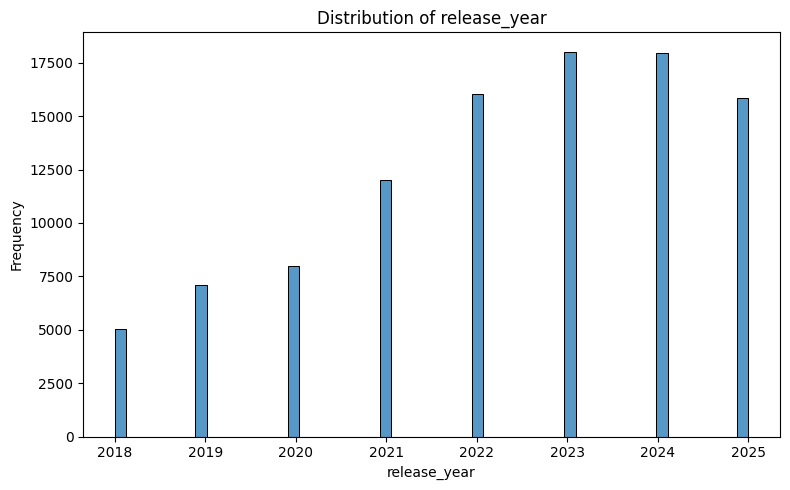

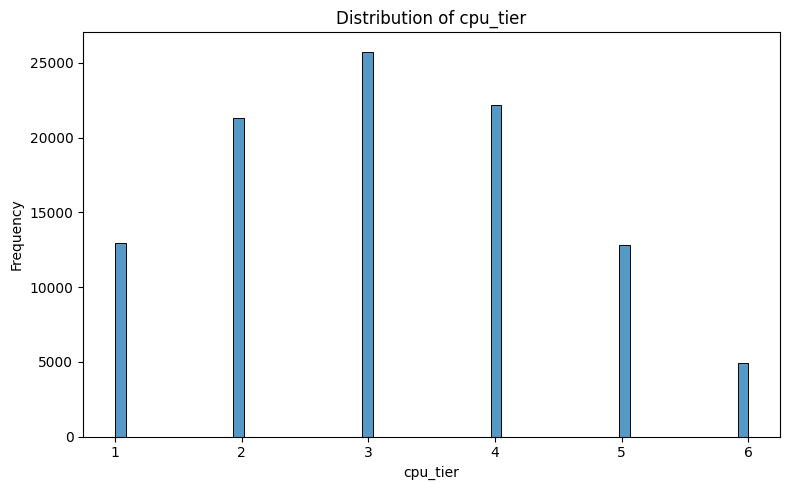

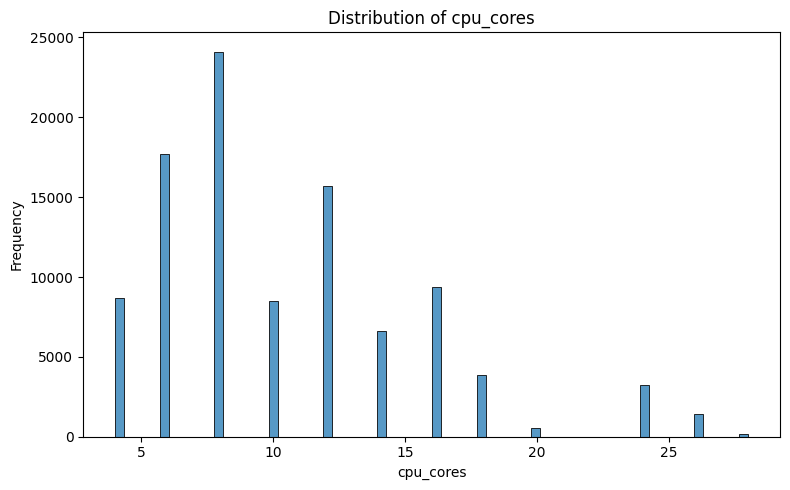

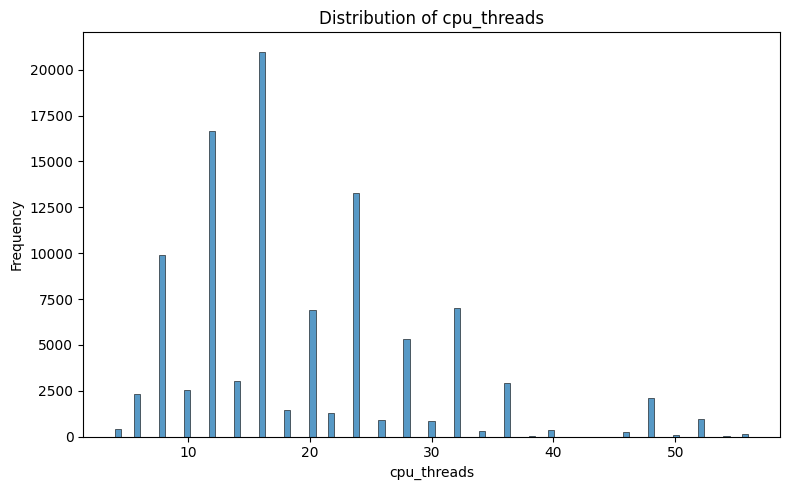

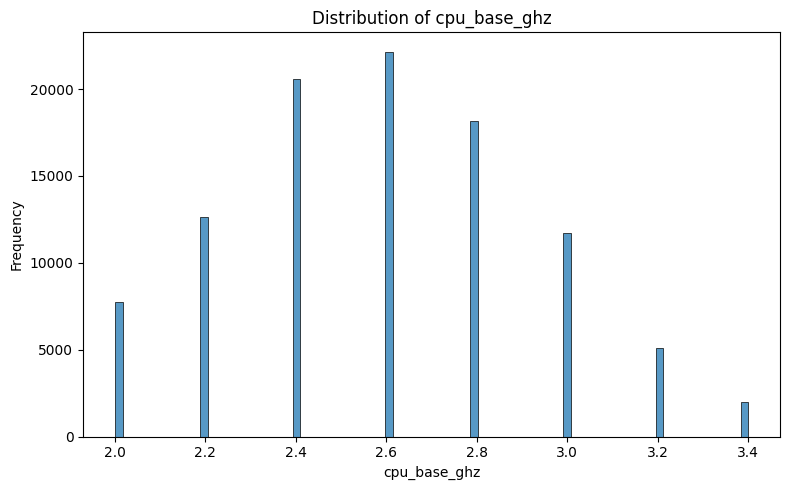

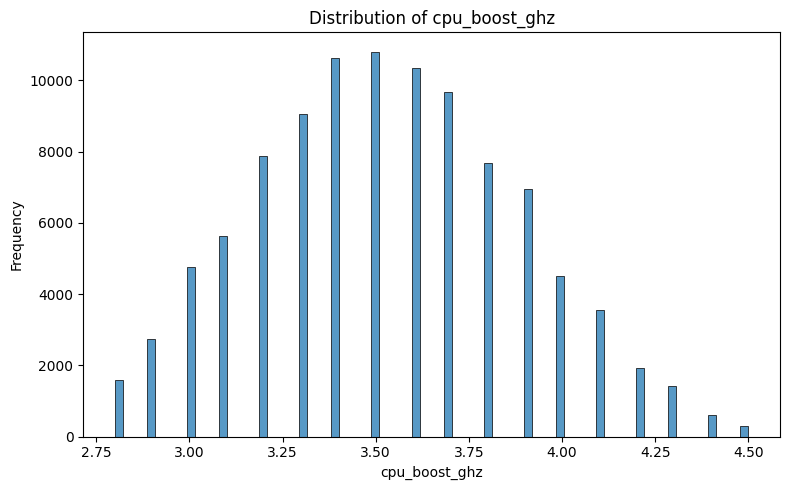

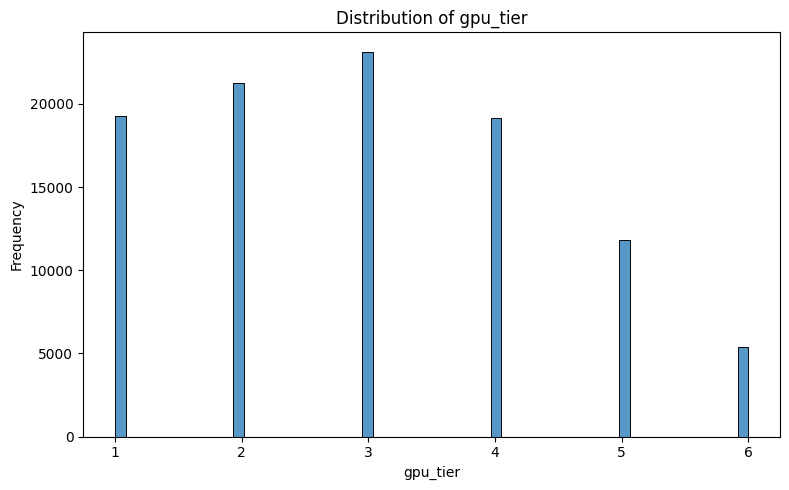

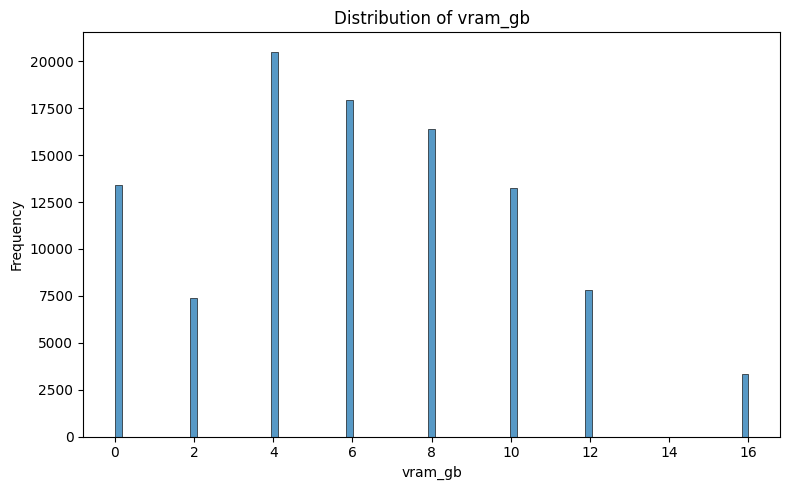

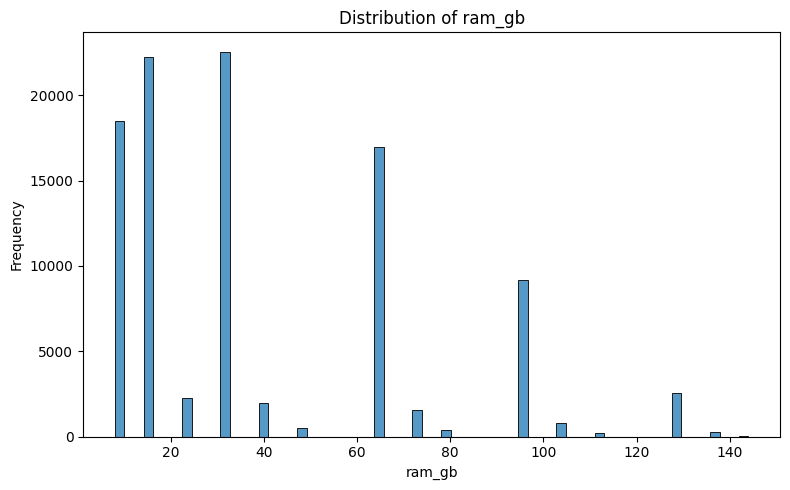

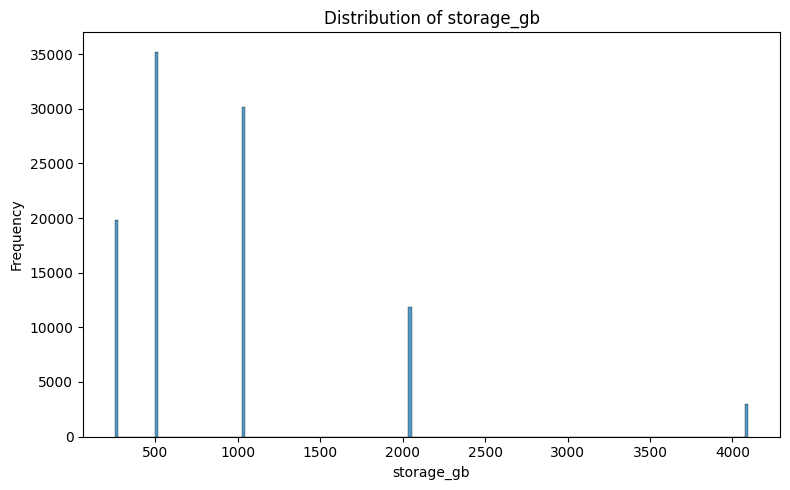

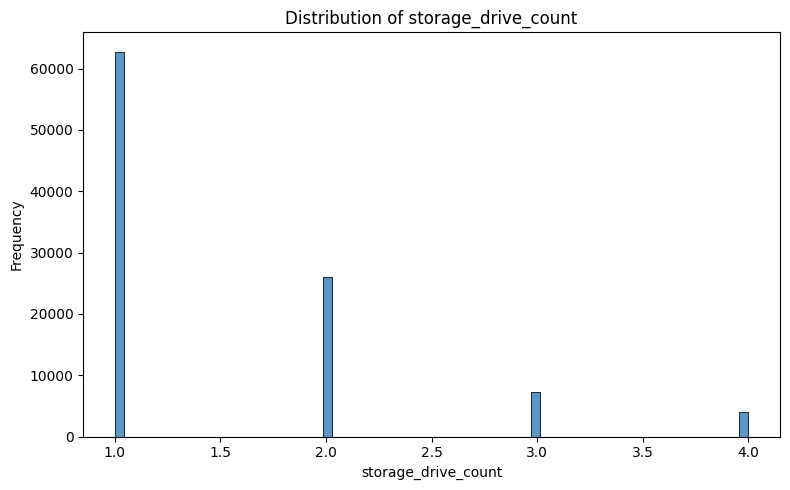

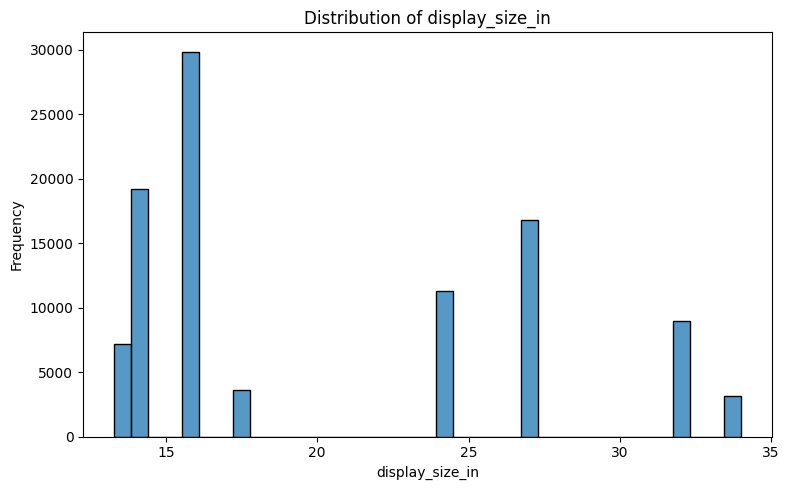

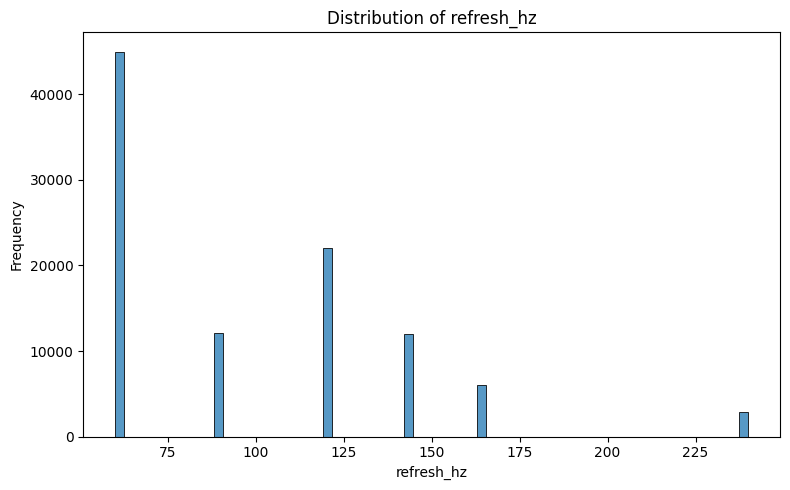

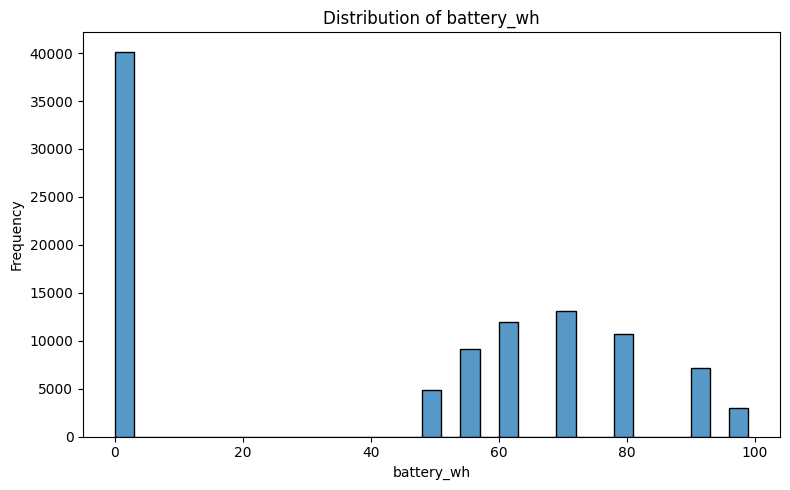

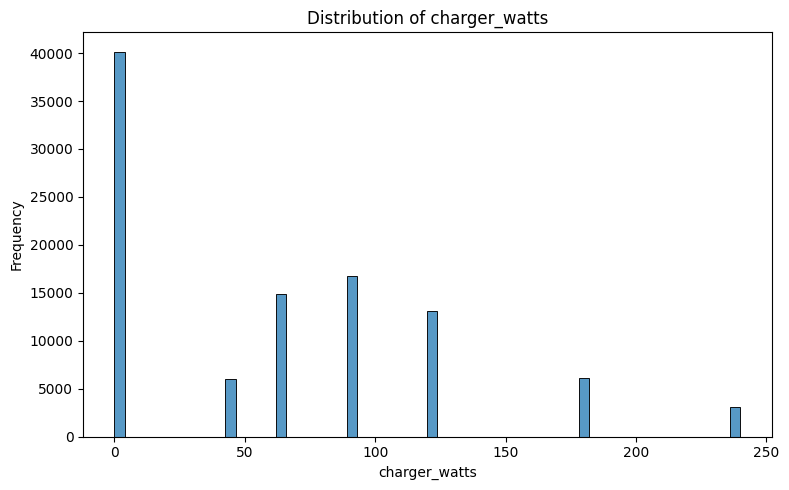

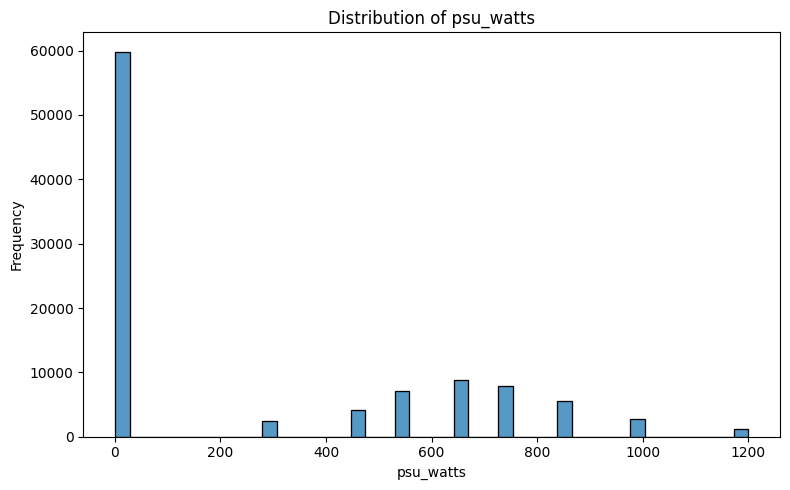

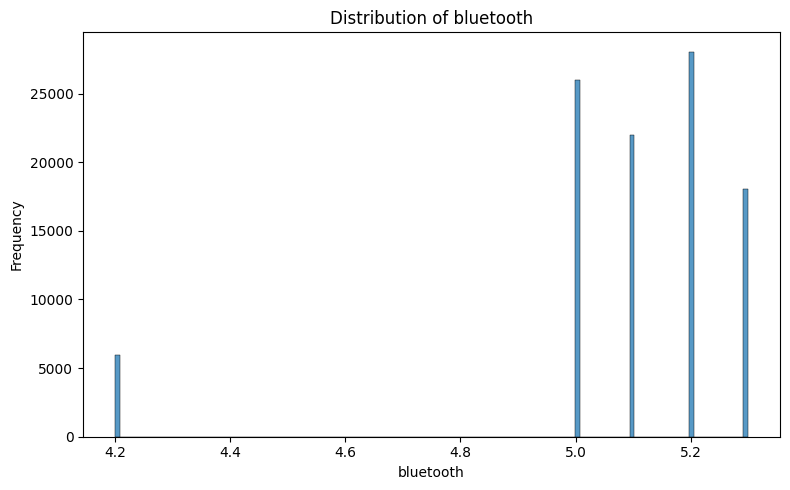

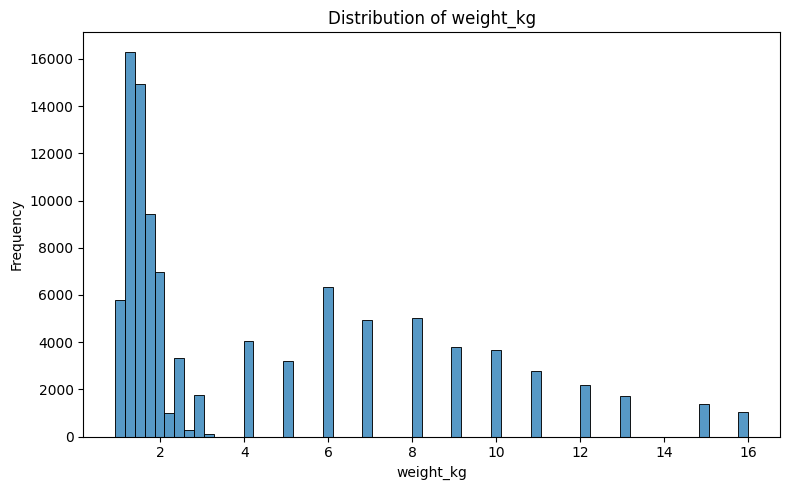

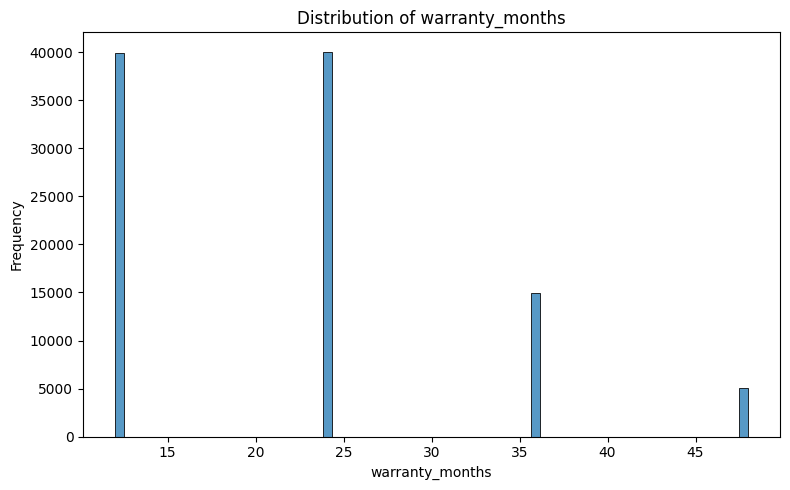

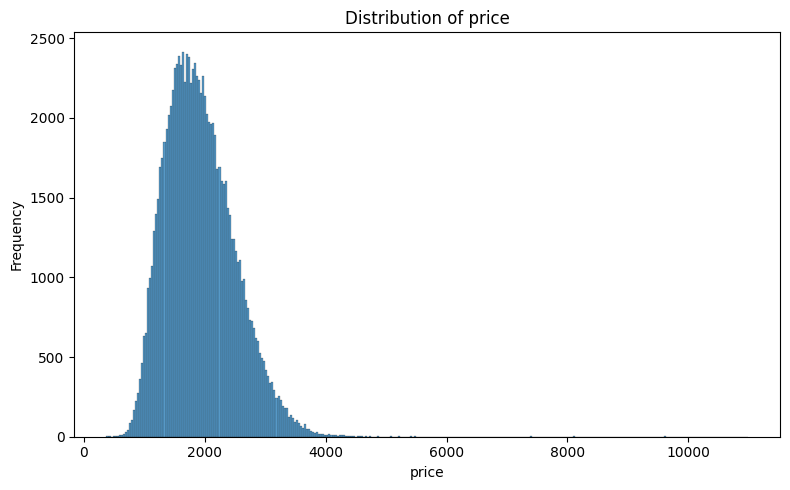

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

for col in num_cols:
    plt.figure(figsize=(8, 5))
    sns.histplot(df[col])
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()

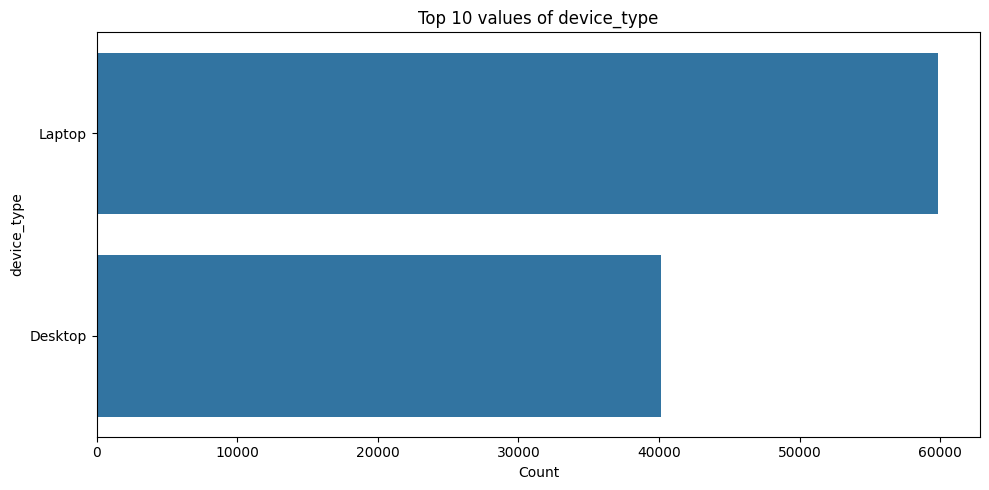

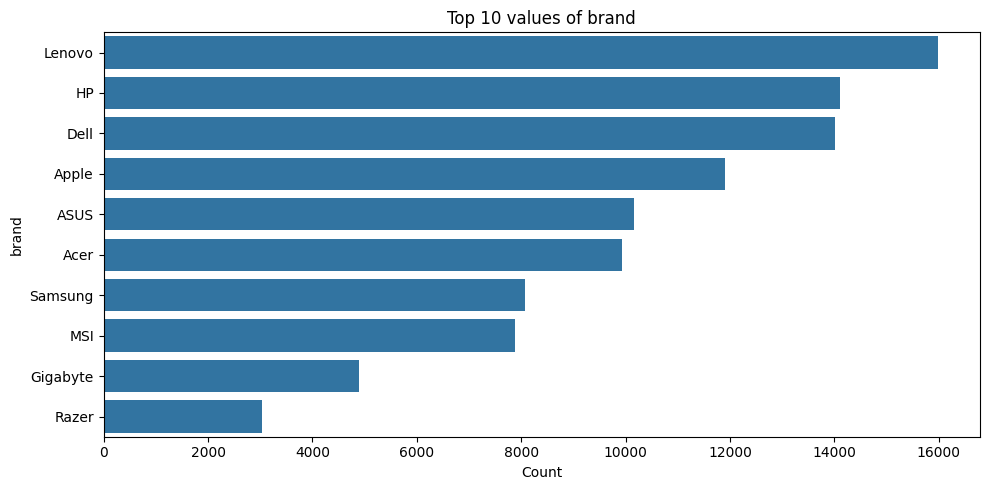

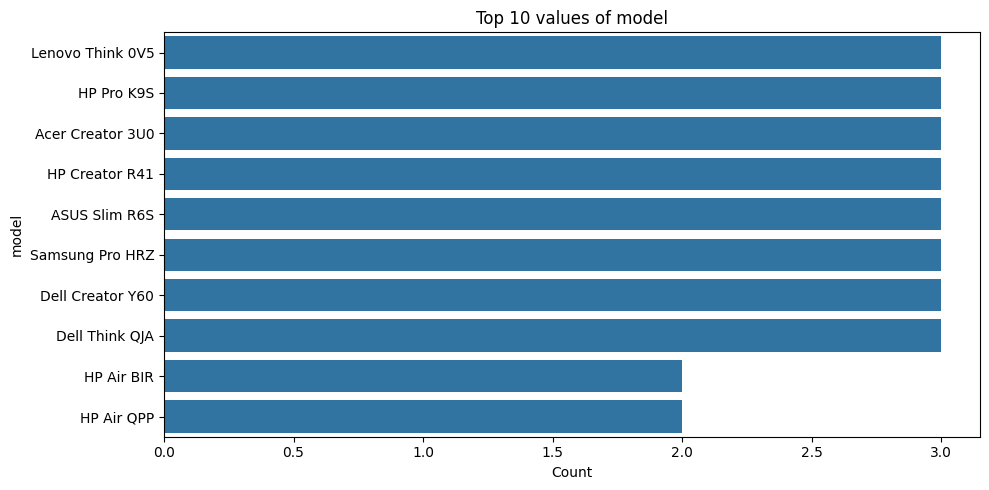

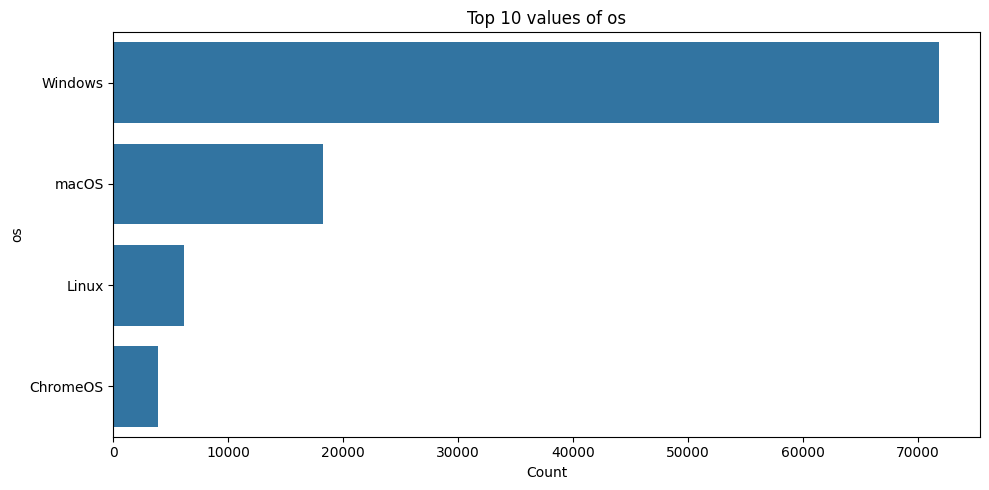

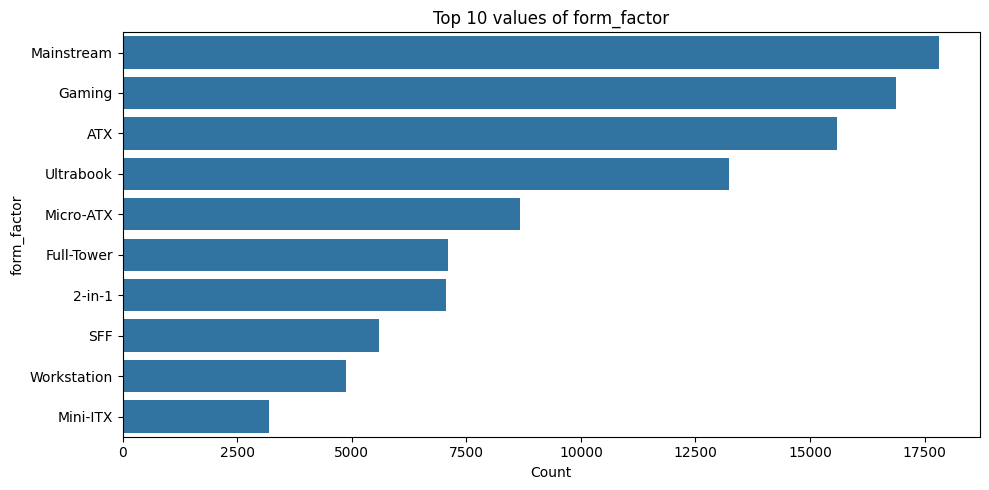

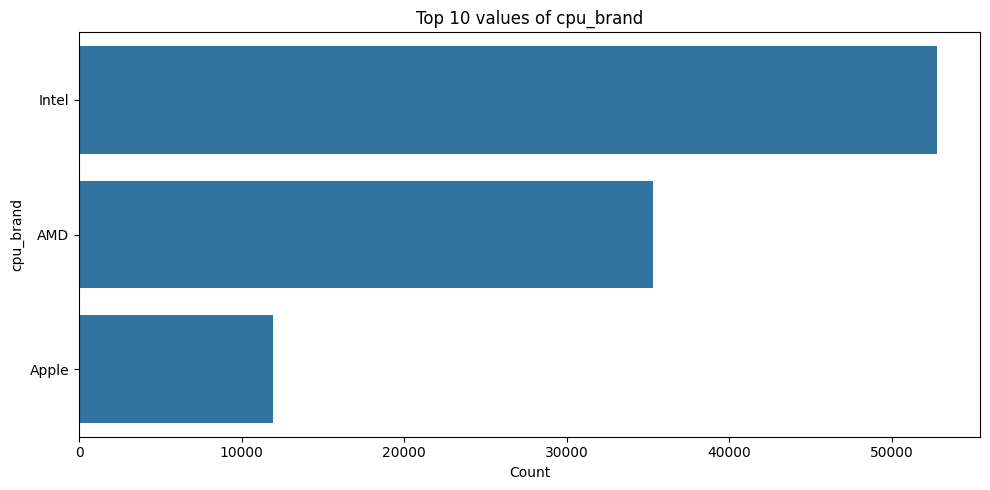

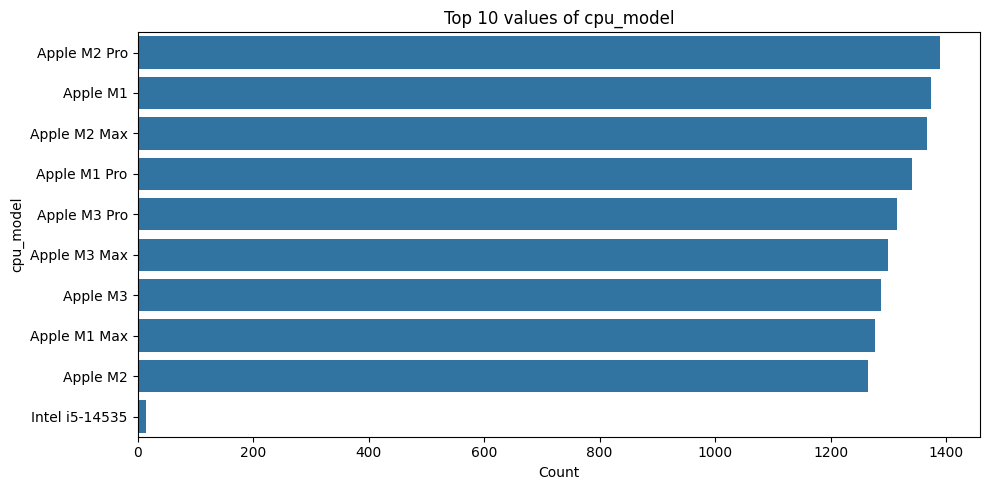

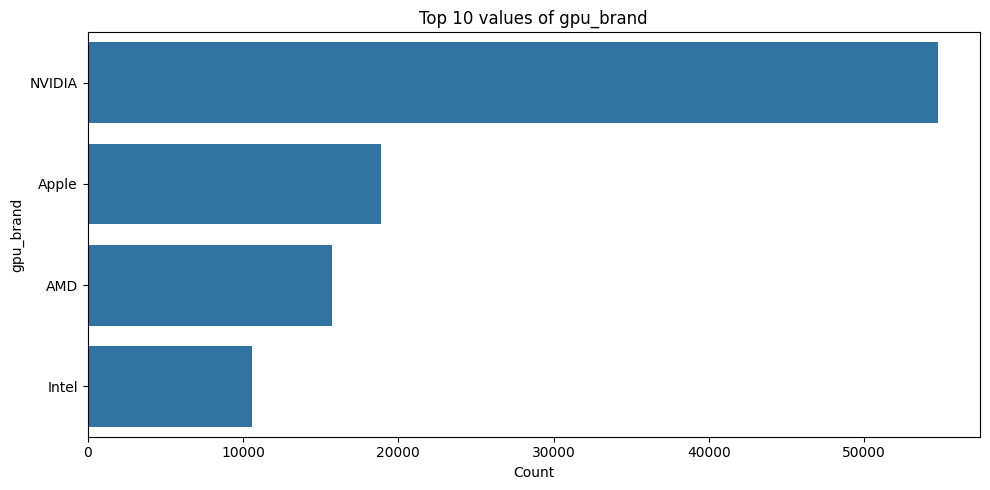

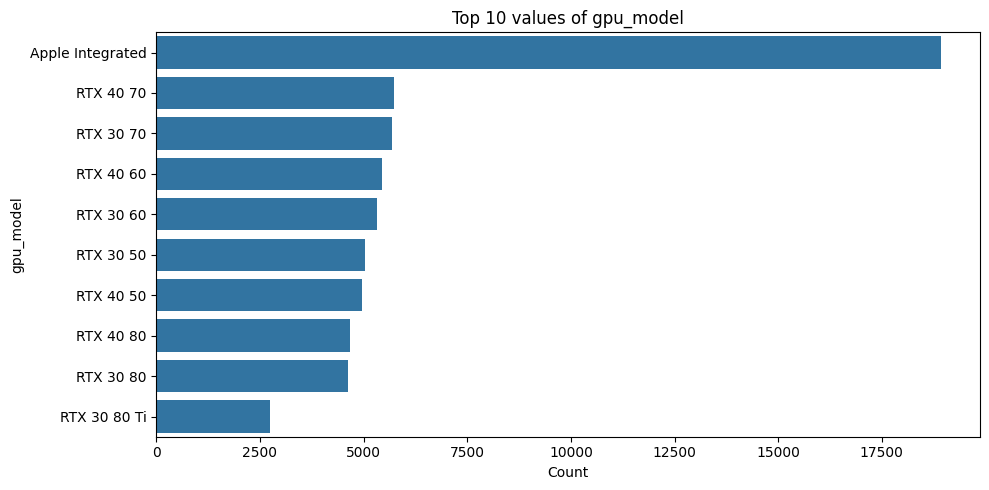

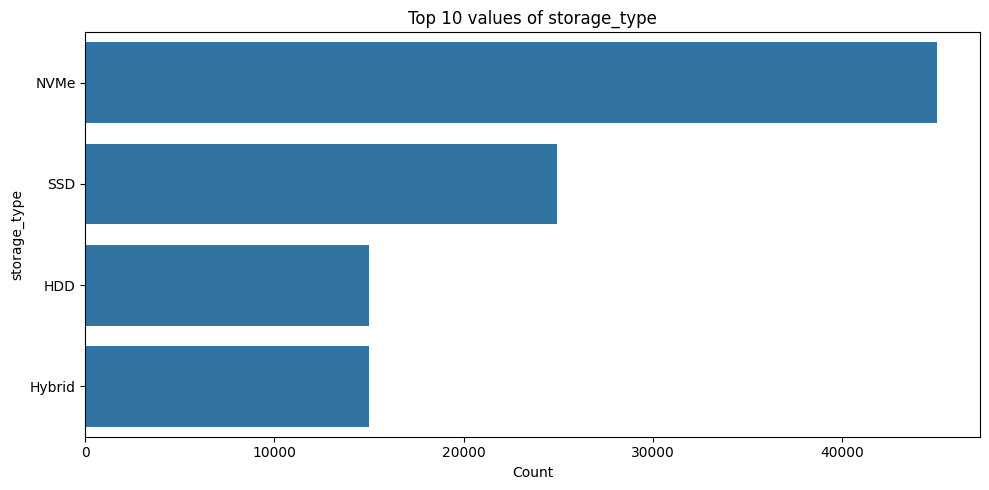

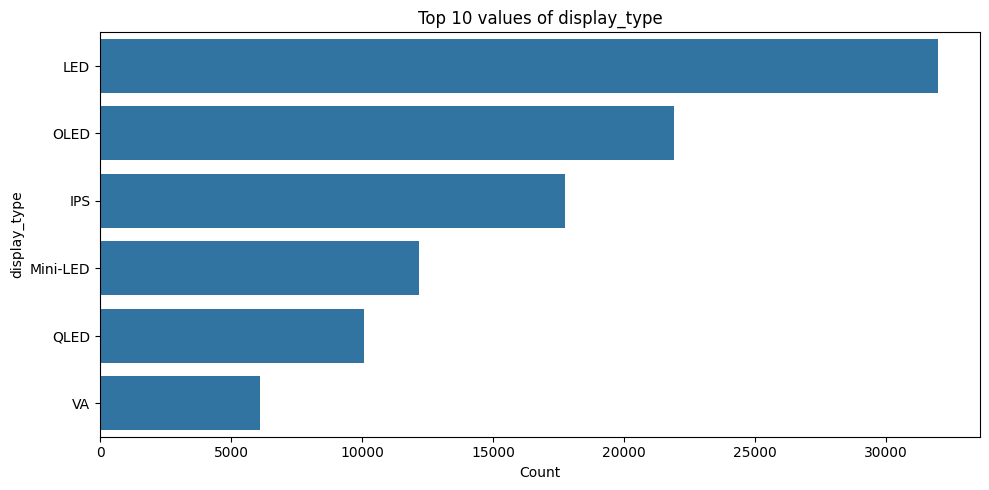

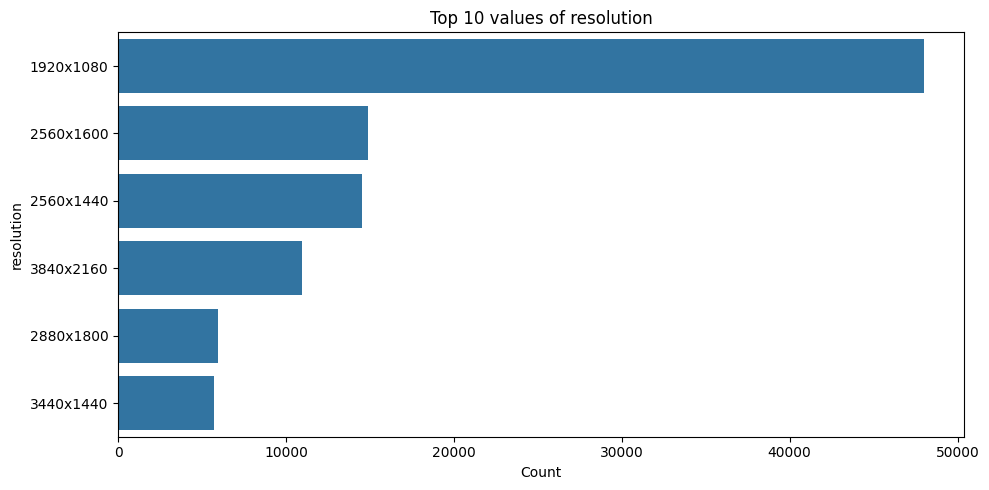

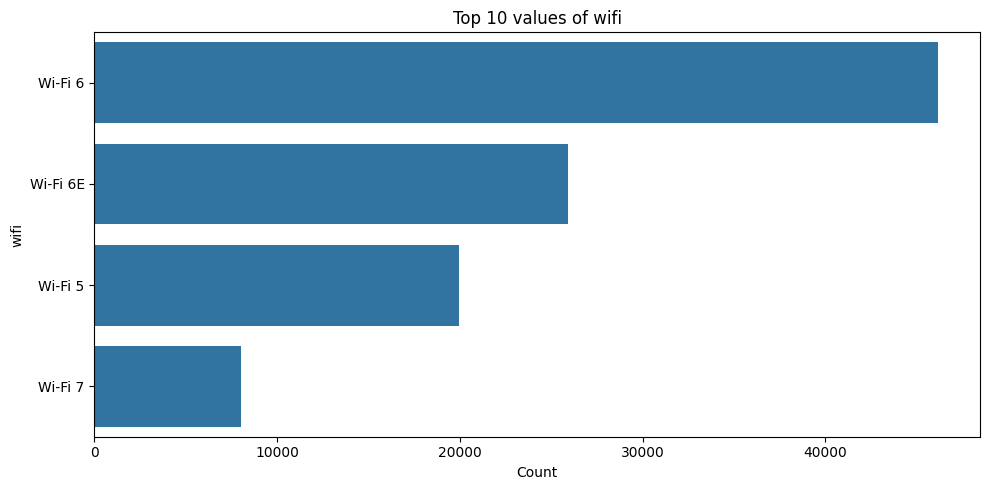

In [ ]:
for col in cat_cols:
    plt.figure(figsize=(10, 5))

    top_values = df[col].value_counts().head(10).index
    sns.countplot(
        y=df[col],
        order=top_values
    )

    plt.title(f'Top 10 values of {col}')
    plt.xlabel('Count')
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

In [ ]:
print(f"Number of unique models: {df['model'].nunique()}")
print(f"Number of unique CPU models: {df['cpu_model'].nunique()}")

Number of unique models: 99036
Number of unique CPU models: 26971


In [ ]:
def classify_cpu_model(cpu_model):
    cpu_model_lower = str(cpu_model).lower()
    if 'intel i3' in cpu_model_lower:
        return 'Intel i3'
    elif 'intel i5' in cpu_model_lower:
        return 'Intel i5'
    elif 'intel i7' in cpu_model_lower:
        return 'Intel i7'
    elif 'intel i9' in cpu_model_lower:
        return 'Intel i9'
    elif 'amd ryzen 3' in cpu_model_lower:
        return 'AMD Ryzen 3'
    elif 'amd ryzen 5' in cpu_model_lower:
        return 'AMD Ryzen 5'
    elif 'amd ryzen 7' in cpu_model_lower:
        return 'AMD Ryzen 7'
    elif 'amd ryzen 9' in cpu_model_lower:
        return 'AMD Ryzen 9'
    elif 'apple m1' in cpu_model_lower or 'apple m2' in cpu_model_lower or 'apple m3' in cpu_model_lower:
        return 'Apple M-series'
    elif 'intel' in cpu_model_lower:
        return 'Other Intel'
    elif 'amd' in cpu_model_lower:
        return 'Other AMD'
    elif 'apple' in cpu_model_lower:
        return 'Other Apple'
    else:
        return 'Other'

df['cpu_category'] = df['cpu_model'].apply(classify_cpu_model)

print("CPU Category distribution:")
print(df['cpu_category'].value_counts())

cpu_category_total = df['cpu_category'].value_counts().sum()
print(f"Total CPU Categories: {cpu_category_total}")


CPU Category distribution:
cpu_category
Intel i5          25233
Intel i7          17991
AMD Ryzen 5       17014
AMD Ryzen 7       11976
Apple M-series    11915
Intel i3           7354
AMD Ryzen 3        4966
Intel i9           2196
AMD Ryzen 9        1355
Name: count, dtype: int64
Total CPU Categories: 100000


In [ ]:
_device_type_map = ['Desktop', 'Laptop']
_brand_map = ['Samsung', 'Lenovo', 'Dell', 'Gigabyte', 'MSI', 'Apple', 'HP', 'Acer', 'ASUS', 'Razer']
_os_map = ['Windows', 'macOS', 'Linux', 'ChromeOS']
_form_factor_map = ['ATX', 'Mainstream', 'SFF', 'Gaming', 'Micro-ATX', 'Ultrabook', '2-in-1', 'Mini-ITX', 'Full-Tower', 'Workstation']
_cpu_brand_map = ['Intel', 'AMD', 'Apple']
_cpu_category_map = ['Intel i3', 'Intel i5', 'Intel i7', 'Intel i9', 'AMD Ryzen 3', 'AMD Ryzen 5', 'AMD Ryzen 7', 'AMD Ryzen 9', 'Apple M-series']
_gpu_brand_map = ['NVIDIA', 'AMD', 'Apple', 'Intel']
_gpu_model_map = ['RTX 40 60', 'RTX 40 80', 'RTX 40 50', 'RX 7000 60', 'RTX 30 80 Ti',
 'RTX 40 90', 'Apple Integrated', 'RTX 30 50', 'RTX 30 60', 'RX 6000 80',
 'RTX 30 70', 'RTX 40 80 Ti', 'RTX 40 70', 'RX 7000 80 XT', 'RX 5000 50',
 'RX 5000 90', 'RTX 30 80', 'RX 7000 80', 'RTX 30 90', 'RX 6000 60', 'Arc A310',
 'RX 7000 50', 'RX 6000 70', 'RX 6000 90', 'Arc A580', 'Arc B380', 'RX 6000 50',
 'RTX 20 80', 'RX 6000 80 XT', 'RTX 20 70', 'Arc A770', 'RTX 20 60',
 'RTX 20 50', 'Arc A700', 'RX 7000 70', 'Arc A380', 'Arc B700',
 'Arc B770 Limited', 'RX 5000 80', 'RX 7000 90', 'Arc B580', 'RX 5000 60',
 'RTX 20 80 Ti', 'Arc B310', 'Arc B770', 'Arc A770 Limited', 'RX 5000 80 XT',
 'RTX 20 90', 'RX 5000 70']
_storage_type_map = ['NVMe', 'HDD', 'Hybrid', 'SSD']
_display_type_map = ['LED', 'OLED', 'IPS', 'Mini-LED', 'VA', 'QLED']
_resolution_map = ['2560x1440', '1950x1080', '3440x1440', '2560x1600', '3840x2160', '2880x1800']
_wifi_map = ['Wi-Fi 6', 'Wi-Fi 5', 'Wi-Fi 6E', 'Wi-Fi 7']

In [ ]:
mapping_lists = {
    'device_type': _device_type_map,
    'brand': _brand_map,
    'os': _os_map,
    'form_factor': _form_factor_map,
    'cpu_brand': _cpu_brand_map,
    'cpu_category': _cpu_category_map,
    'gpu_brand': _gpu_brand_map,
    'gpu_model': _gpu_model_map,
    'storage_type': _storage_type_map,
    'display_type': _display_type_map,
    'resolution': _resolution_map,
    'wifi': _wifi_map
}

for col_name, map_list in mapping_lists.items():
    value_to_int = {value: index for index, value in enumerate(map_list)}
    df[f'int_{col_name}'] = df[col_name].map(value_to_int)

print("First 5 rows with new integer-encoded columns:")
print(df[['device_type', 'int_device_type', 'cpu_brand', 'int_cpu_brand', 'gpu_brand', 'int_gpu_brand']].head())

First 5 rows with new integer-encoded columns:
  device_type  int_device_type cpu_brand  int_cpu_brand gpu_brand  \
0     Desktop                0     Intel              0    NVIDIA   
1      Laptop                1     Intel              0    NVIDIA   
2     Desktop                0       AMD              1    NVIDIA   
3     Desktop                0       AMD              1       AMD   
4      Laptop                1       AMD              1    NVIDIA   

   int_gpu_brand  
0              0  
1              0  
2              0  
3              1  
4              0  


In [ ]:
max_price = df['price'].max()
min_price = df['price'].min()

print(f"Maximum Price: {max_price}")
print(f"Minimum Price: {min_price}")

Maximum Price: 10984.99
Minimum Price: 372.99


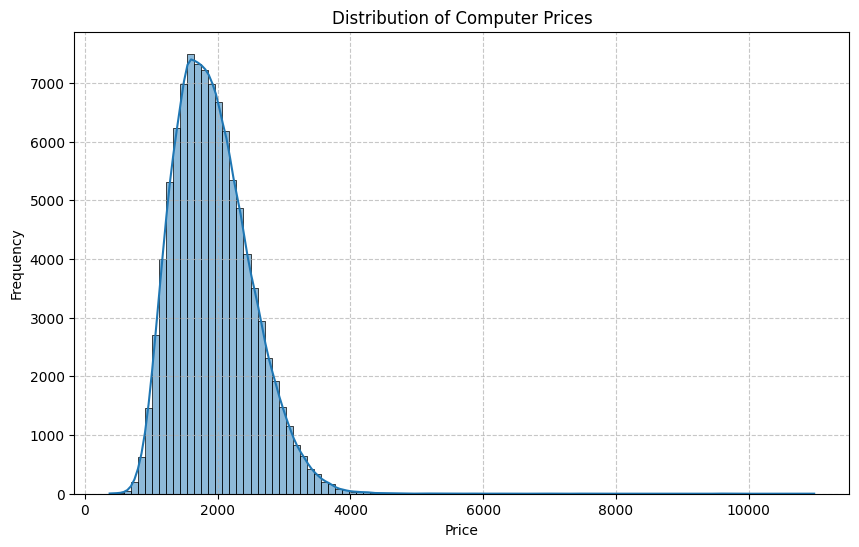

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(df['price'], bins=100, kde=True)
plt.title('Distribution of Computer Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [ ]:
import numpy as np
import pandas as pd

gap = 25
labels = np.arange(300, 11001, gap)

first_edge = labels[0] - gap / 2.0
last_edge = labels[-1] + gap / 2.0
bins_edges = np.arange(first_edge, last_edge + gap, gap)

df['predicted_price'] = pd.cut(
    df['price'],
    bins=bins_edges,
    labels=labels,
    right=True,
    include_lowest=True
)

print(df[['price', 'predicted_price']].head(100))

      price predicted_price
0   1383.99            1375
1   2274.99            2275
2   1879.99            1875
3   1331.99            1325
4   2681.99            2675
..      ...             ...
95  2060.99            2050
96  2564.99            2575
97  1919.99            1925
98  1833.99            1825
99  1418.99            1425

[100 rows x 2 columns]


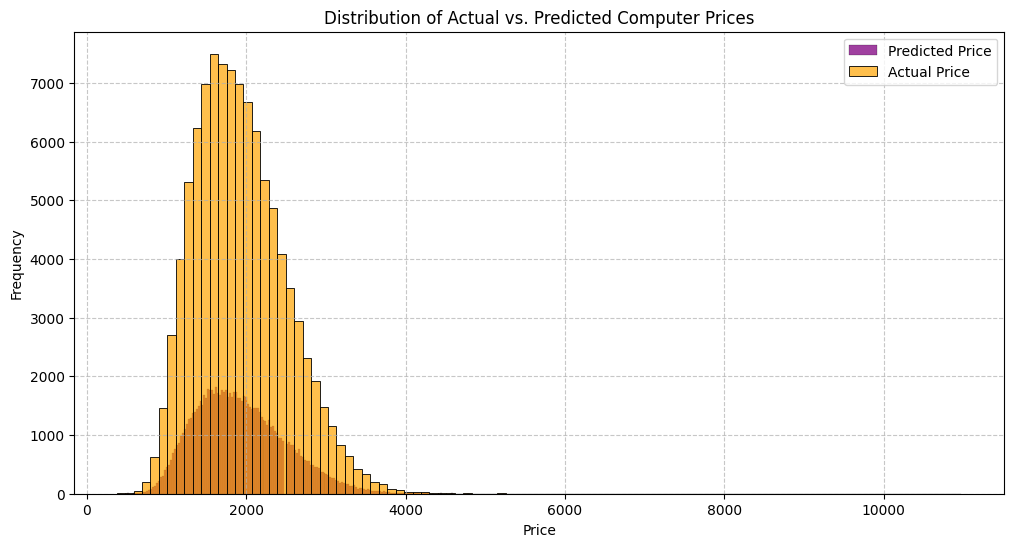

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.histplot(df['predicted_price'].astype(float), bins=labels.size, kde=False, color='purple', label='Predicted Price')
sns.histplot(df['price'], bins=100, kde=False, color='orange', alpha=0.7, label='Actual Price')
plt.title('Distribution of Actual vs. Predicted Computer Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

Correlation with 'predicted_price':
predicted_price        1.000000
price                  0.999923
gpu_tier               0.762816
cpu_tier               0.759135
ram_gb                 0.758576
cpu_cores              0.720403
cpu_threads            0.577471
cpu_base_ghz           0.529840
cpu_boost_ghz          0.508441
vram_gb                0.304974
battery_wh             0.147256
charger_watts          0.126319
release_year           0.089750
storage_gb             0.088954
refresh_hz             0.077223
bluetooth              0.002106
warranty_months       -0.002124
storage_drive_count   -0.082447
weight_kg             -0.130768
psu_watts             -0.140559
display_size_in       -0.143453
dtype: float64


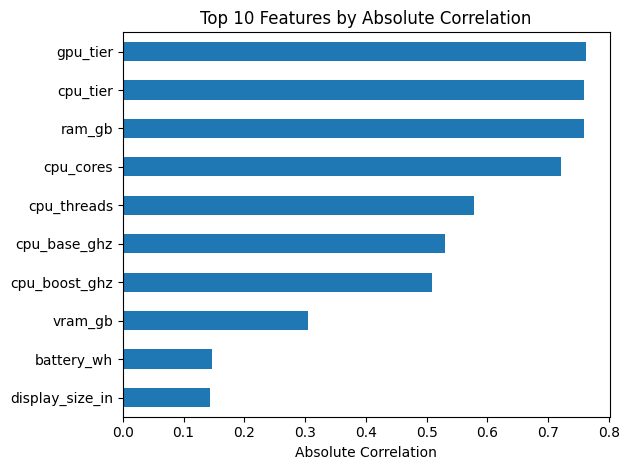

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

df['predicted_price'] = df['predicted_price'].astype(float)

df_encoded = df.copy()
le = LabelEncoder()

numerical_df = df_encoded.select_dtypes(include=['number'])

correlations = numerical_df.corrwith(
    numerical_df['predicted_price']
).sort_values(ascending=False)

print("Correlation with 'predicted_price':")
print(correlations)

top_corr = (
    correlations
    .drop('predicted_price')
    .drop('price')
    .abs()
    .sort_values(ascending=True)
    .tail(10)
)

plt.figure()
top_corr.plot(kind='barh')
plt.title("Top 10 Features by Absolute Correlation")
plt.xlabel("Absolute Correlation")
plt.tight_layout()
plt.show()

Top 10 Feature Importance:
release_year     53.721297
ram_gb           55.385481
display_type     65.632969
os               90.105537
resolution      112.833290
cpu_tier        121.947004
device_type     139.416259
cpu_cores       249.564815
gpu_tier        251.023495
cpu_threads     254.839588
dtype: float64


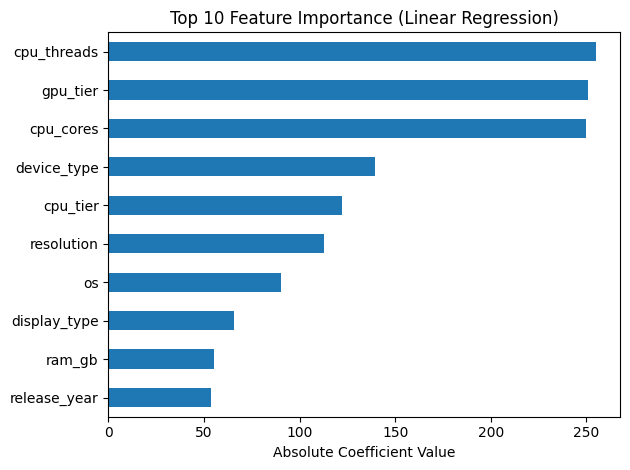

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

df['predicted_price'] = df['predicted_price'].astype(float)

df_encoded = df.copy()
le = LabelEncoder()

for col in df_encoded.select_dtypes(include=['object']).columns:
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))

X = df_encoded.drop(columns=['predicted_price', 'price'])
y = df_encoded['predicted_price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LinearRegression()
model.fit(X_train_scaled, y_train)

importance = pd.Series(
    model.coef_,
    index=X.columns
)

top_importance = (
    importance
    .abs()
    .sort_values(ascending=True)
    .tail(10)
)

print("Top 10 Feature Importance:")
print(top_importance)

plt.figure()
top_importance.plot(kind='barh')
plt.title("Top 10 Feature Importance (Linear Regression)")
plt.xlabel("Absolute Coefficient Value")
plt.tight_layout()
plt.show()

In [ ]:
group_cols = [
    "gpu_tier",
    "cpu_tier",
    "ram_gb",
    "cpu_cores",
    "cpu_threads",
    "cpu_base_ghz",
    "cpu_boost_ghz",
]

df_group = (
    df
    .groupby(group_cols, as_index=False)
    .agg(avg_price=("price", "mean"))
)

np.random.seed(42)
df_group["noise"] = np.random.uniform(-0.10, 0.10, size=len(df_group))

df_group["price_noised"] = (
    df_group["avg_price"] * (1 + df_group["noise"])
)

df_group["is_worth"] = (df_group["noise"] >= 0.05).astype(int)

df_group = df.merge(
    df_group[group_cols + ["is_worth", "price_noised"]],
    on=group_cols,
    how="left"
)

df_group.head()

,device_type,brand,model,release_year,os,form_factor,cpu_brand,cpu_model,cpu_tier,cpu_cores,...,int_cpu_category,int_gpu_brand,int_gpu_model,int_storage_type,int_display_type,int_resolution,int_wifi,predicted_price,is_worth,price_noised
0,Desktop,Samsung,Samsung Forge XDI,2022,Windows,ATX,Intel,Intel i5-11129,3,12,...,1,0,0,0,0,0.0,0,1375.0,0,1391.773707
1,Laptop,Samsung,Samsung Pro KM8,2022,Windows,Mainstream,Intel,Intel i7-11114,4,12,...,2,0,1,0,1,NaN,0,2275.0,1,2464.381185
2,Desktop,Lenovo,Lenovo Strix BIE,2024,macOS,SFF,AMD,AMD Ryzen 5 5168,2,8,...,5,0,2,0,0,2.0,0,1875.0,1,1407.328635
3,Desktop,Dell,Dell Cube AXR,2024,Windows,ATX,AMD,AMD Ryzen 5 7550,2,6,...,5,1,3,1,2,2.0,0,1325.0,1,1569.914229
4,Laptop,Gigabyte,Gigabyte Pro IX1,2024,Linux,Gaming,AMD,AMD Ryzen 7 6230,5,16,...,6,0,4,0,3,3.0,0,2675.0,0,2724.117789


In [ ]:
df_group[group_cols + ["is_worth", "price_noised"]].head()

,gpu_tier,cpu_tier,ram_gb,cpu_cores,cpu_threads,cpu_base_ghz,cpu_boost_ghz,is_worth,price_noised
0,2,3,16,12,24,2.8,3.8,0,1391.773707
1,4,4,64,12,24,2.6,3.6,1,2464.381185
2,1,2,8,8,16,2.6,3.6,1,1407.328635
3,2,2,16,6,12,2.6,3.6,1,1569.914229
4,5,5,96,16,32,2.8,3.9,0,2724.117789


In [ ]:
corr_series = (
    df_group[group_cols + ["is_worth", "price_noised"]]
    .corr()["is_worth"]
    .drop("is_worth")
    .sort_values(ascending=False)
)

print("Correlation with is_worth:")
print(corr_series)

Correlation with is_worth:
price_noised     0.202870
cpu_boost_ghz    0.095577
cpu_base_ghz     0.087406
gpu_tier         0.080207
ram_gb           0.070338
cpu_threads      0.064336
cpu_cores        0.063763
cpu_tier         0.062838
Name: is_worth, dtype: float64


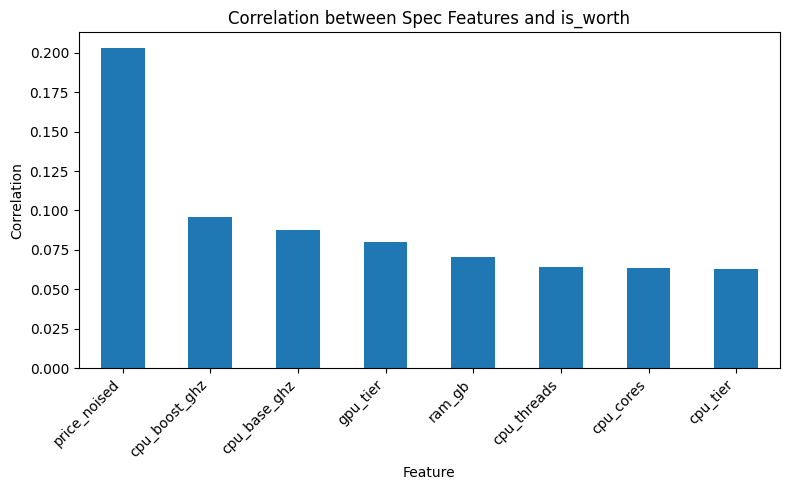

In [ ]:
plt.figure(figsize=(8, 5))
corr_series.plot(kind="bar")
plt.title("Correlation between Spec Features and is_worth")
plt.ylabel("Correlation")
plt.xlabel("Feature")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()
